In [1]:
import joblib
import pandas as pd
import numpy as np
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

import sys
sys.path.append('..')
from utils.extract_features import extract_features

In [2]:
df = pd.read_csv("../XSS_dataset.csv")
print("Извлечение признаков...")
features_list = []
for i, text in enumerate(df['text']):
    if i % 500 == 0:
        print(f"Обработано {i}/{len(df)}")
    features_list.append(extract_features(text, False))

X = pd.DataFrame(features_list)
y = df['label'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Извлечение признаков...
Обработано 0/13686
Обработано 500/13686
Обработано 1000/13686
Обработано 1500/13686
Обработано 2000/13686
Обработано 2500/13686
Обработано 3000/13686
Обработано 3500/13686
Обработано 4000/13686
Обработано 4500/13686
Обработано 5000/13686
Обработано 5500/13686
Обработано 6000/13686
Обработано 6500/13686
Обработано 7000/13686
Обработано 7500/13686
Обработано 8000/13686
Обработано 8500/13686
Обработано 9000/13686
Обработано 9500/13686
Обработано 10000/13686
Обработано 10500/13686
Обработано 11000/13686
Обработано 11500/13686
Обработано 12000/13686
Обработано 12500/13686
Обработано 13000/13686
Обработано 13500/13686


In [3]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [4]:
print("Обучение SVM")
svm = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
svm.fit(X_train_scaled, y_train)

Обучение SVM


,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [5]:
y_pred = svm.predict(X_test_scaled)
y_proba = svm.predict_proba(X_test_scaled)[:, 1]

print("\n=== Отчёт ===")
print(classification_report(y_test, y_pred))
print(f"AUC: {roc_auc_score(y_test, y_proba):.4f}")


=== Отчёт ===
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1263
           1       1.00      1.00      1.00      1475

    accuracy                           1.00      2738
   macro avg       1.00      1.00      1.00      2738
weighted avg       1.00      1.00      1.00      2738

AUC: 0.9988


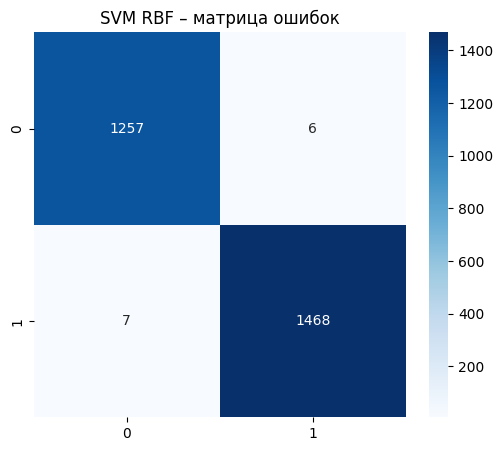

In [6]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("SVM RBF – матрица ошибок")
plt.savefig("svm_confusion.png")
plt.show()

In [7]:
joblib.dump(svm, "svm_rbf_xss.pkl")
joblib.dump(scaler, "svm_scaler.pkl")
print("Модель и scaler сохранены.")

Модель и scaler сохранены.



ОЦЕНКА НА ТЕСТОВОМ ДАТАСЕТЕ (SVM)
Загружено 13226 тестовых примеров
Извлечение признаков: 0/13226
Извлечение признаков: 500/13226
Извлечение признаков: 1000/13226
Извлечение признаков: 1500/13226
Извлечение признаков: 2000/13226
Извлечение признаков: 2500/13226
Извлечение признаков: 3000/13226
Извлечение признаков: 3500/13226
Извлечение признаков: 4000/13226
Извлечение признаков: 4500/13226
Извлечение признаков: 5000/13226
Извлечение признаков: 5500/13226
Извлечение признаков: 6000/13226
Извлечение признаков: 6500/13226
Извлечение признаков: 7000/13226
Извлечение признаков: 7500/13226
Извлечение признаков: 8000/13226
Извлечение признаков: 8500/13226
Извлечение признаков: 9000/13226
Извлечение признаков: 9500/13226
Извлечение признаков: 10000/13226
Извлечение признаков: 10500/13226
Извлечение признаков: 11000/13226
Извлечение признаков: 11500/13226
Извлечение признаков: 12000/13226
Извлечение признаков: 12500/13226
Извлечение признаков: 13000/13226
              precision    recall  f1

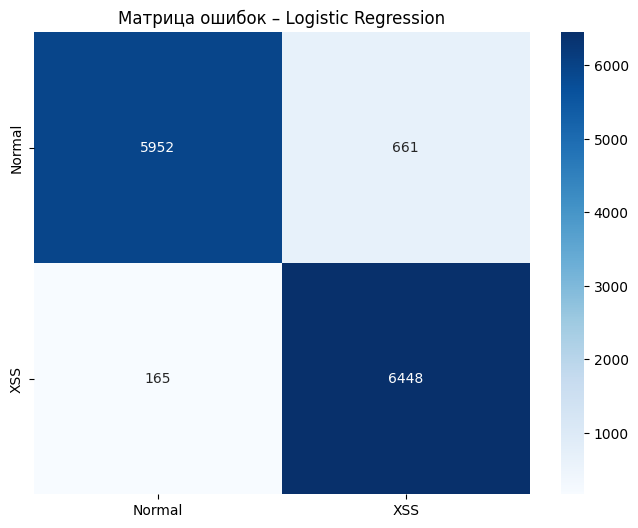


Точность: 93.75%
Precision: 90.70%, Recall: 97.50%, F1: 93.98%

🧪 Примеры:
<script>alert('XSS')</script>: XSS=True (prob=99.69%)
<div>Hello</div>: XSS=False (prob=0.74%)


In [12]:
# ========== БЛОК ОЦЕНКИ НА ТЕСТОВОМ ДАТАСЕТЕ (LR) ==========
print("\n" + "="*60)
print("ОЦЕНКА НА ТЕСТОВОМ ДАТАСЕТЕ (SVM)")
print("="*60)

test_df = pd.read_csv("../datasets_test/xss_dataset.csv")
print(f"Загружено {len(test_df)} тестовых примеров")

# Извлечение признаков для теста
test_features = []
for i, text in enumerate(test_df['text']):
    if i % 500 == 0:
        print(f"Извлечение признаков: {i}/{len(test_df)}")
    test_features.append(extract_features(text, False))

X_test_full = pd.DataFrame(test_features)
# Масштабируем с тем же scaler
X_test_scaled = scaler.transform(X_test_full)
y_test_full = test_df['label'].values

# Предсказания
y_pred_full = svm.predict(X_test_scaled)
y_proba_full = svm.predict_proba(X_test_scaled)[:, 1]

# Метрики
print(classification_report(y_test_full, y_pred_full))
print(f"AUC: {roc_auc_score(y_test_full, y_proba_full):.4f}")

# Матрица ошибок
cm_full = confusion_matrix(y_test_full, y_pred_full)
plt.figure(figsize=(8,6))
sns.heatmap(cm_full, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'XSS'], yticklabels=['Normal', 'XSS'])
plt.title('Матрица ошибок – Logistic Regression')
plt.savefig('svm_test_confusion.png')
plt.show()

TN, FP, FN, TP = cm_full.ravel()
print(f"\nТочность: {(TP+TN)/(TP+TN+FP+FN):.2%}")
print(f"Precision: {TP/(TP+FP):.2%}, Recall: {TP/(TP+FN):.2%}, F1: {2*TP/(2*TP+FP+FN):.2%}")

# Тест на примерах
test_cases = [
    ("<script>alert('XSS')</script>", True),
    ("<div>Hello</div>", False),
]
print("\n🧪 Примеры:")
for code, expected in test_cases:
    feat = extract_features(code, False)
    feat_df = pd.DataFrame([feat])
    feat_scaled = scaler.transform(feat_df)
    prob = svm.predict_proba(feat_scaled)[0][1]
    print(f"{code[:40]}: XSS={prob>=0.5} (prob={prob:.2%})")